<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/comparaisons_photometrie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recherche de comparaisons photométriques

Sélection d'étoiles de comparaison dans le champ d'un instrument, pour photométrie
différentielle — notamment la calibration en flux des spectres selon la méthode de Boyd.

**Principe** : la liste de candidates est bâtie sur Gaia DR3 (complet et homogène), puis
chaque source est appariée aux catalogues photométriques par position. La magnitude V
retenue suit une hiérarchie qui dépend du régime de brillance.

| Régime | Source primaire | Contrôle |
|---|---|---|
| V < 9 | GCPD (photoélectrique) | Gaia, Tycho-2 |
| 9 < V < 10 | Gaia | Tycho-2 |
| V > 10 | APASS DR9 | Gaia |

APASS sature vers V ≈ 7–7.5 et le GCPD s'épuise vers V ≈ 8.5 : les deux se relaient.

**Ordre des cellules** : configuration → requêtes → fusion → classements → carte → export.

In [1]:
!pip install -q astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 53.1 MB/s eta 0:00:00


## 1. Configuration

Seule cette cellule est à modifier d'une cible à l'autre.

In [2]:
# ============================== CIBLE ==============================
TARGET      = "10 lac"   # nom résolvable par SIMBAD, ou None
TARGET_RA   = None          # si TARGET vaut None : "22 39 15.7" ou 339.8154 (deg)
TARGET_DEC  = None          #                        "+39 03 01"  ou  39.0503
TARGET_V    = None          # None = pris dans les catalogues ; sinon impose la valeur
TARGET_BV   = None          # idem

# ============================ INSTRUMENT ===========================
INSTRUMENT = "chercheur30"

INSTRUMENTS = {
    # scale : arcsec/px   nx, ny : taille capteur en px
    # rot_deg : rotation du capteur, positif = nord bascule vers l'est
    #           À CONFIRMER PAR PLATE-SOLVE — 3.0 est une estimation
    # rate_ref / v_ref / adu_max : pic ADU par seconde à v_ref, et plafond utile
    "chercheur30": dict(scale=4.94, nx=1936, ny=1096, rot_deg=3.0,
                        rate_ref=1201/0.30, v_ref=4.00, adu_max=3200),
    "altair60":    dict(scale=2.66, nx=1936, ny=1096, rot_deg=3.0,
                        rate_ref=1201/0.30*4.0, v_ref=4.00, adu_max=3200),
}

# ============================ SÉLECTION ============================
DMAG_BRIGHT  = 0.8    # magnitudes AU-DESSUS de la cible (risque de saturation)
DMAG_FAINT   = 4.0    # magnitudes AU-DESSOUS (la borne réelle est le critère pic)
GMAG_LIMIT   = 13.0   # profondeur Gaia : candidates + détection de compagnons
MATCH_RADIUS = 6.0    # arcsec, appariement inter-catalogues
BLEND_RADIUS = 20     # px, rayon de recherche de compagnons
BLEND_DMAG   = 3.0    # un compagnon compte s'il est à moins de DMAG du primaire
EDGE_MARGIN  = 10     # px, marge de bord : devient une raison de rejet,
                      #     jamais une coupe silencieuse. Mettre 0 pour tout garder.
RUWE_MAX     = 1.4    # au-delà, astrométrie incompatible avec une source ponctuelle
PIC_MIN      = 120    # ADU, pic minimal souhaité à la pose imposée par la cible

# --------------------- CARTE DE POINTAGE ---------------------
PREVIEW_MAG    = 4.5   # profondeur affichée, en magnitudes sous la cible
PREVIEW_FLIP_X = False # à régler une fois, en comparant à une vraie image
PREVIEW_FLIP_Y = False

W_COLOR = 1.0         # poids du critère couleur dans le score combiné
W_MAG   = 1.0         # poids du critère magnitude
NORM_COLOR = 0.30     # écart de couleur "coûtant 1 point"
NORM_MAG   = 1.00     # écart de magnitude "coûtant 1 point"

## 2. Imports et résolution de la cible

In [3]:
import warnings
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.table import Table
from astroquery.vizier import Vizier

warnings.filterwarnings("ignore")

INS   = INSTRUMENTS[INSTRUMENT]
SCALE = INS["scale"]
NX, NY, ROT = INS["nx"], INS["ny"], INS["rot_deg"]
HALF_X, HALF_Y = NX / 2, NY / 2

if TARGET:
    try:
        center = SkyCoord.from_name(TARGET)
    except Exception as exc:
        raise SystemExit(
            f"\nNom « {TARGET} » non résolu ({type(exc).__name__}).\n"
            "  - vérifiez l'orthographe (essayez la forme SIMBAD : "
            "HD 214680, 10 Lac, * 10 Lac)\n"
            "  - ou laissez TARGET = None et renseignez TARGET_RA / TARGET_DEC\n"
            "  - une coupure réseau donne la même erreur : réessayez."
        ) from None
    label_cible = TARGET
else:
    if TARGET_RA is None or TARGET_DEC is None:
        raise SystemExit("\nTARGET vaut None : renseignez TARGET_RA et TARGET_DEC.")
    try:
        ra  = (TARGET_RA if isinstance(TARGET_RA, (int, float))
               else Angle(TARGET_RA, unit=u.hourangle).deg)
        dec = (TARGET_DEC if isinstance(TARGET_DEC, (int, float))
               else Angle(TARGET_DEC, unit=u.deg).deg)
    except Exception as exc:
        raise SystemExit(
            f"\nCoordonnées illisibles ({type(exc).__name__}).\n"
            "  formats acceptés : « 22 39 15.7 » et « +39 03 01 », "
            "ou 339.8154 et 39.0503 en degrés."
        ) from None
    center = SkyCoord(ra * u.deg, dec * u.deg)
    label_cible = "cible"

# boîte de requête : champ du capteur + 10 % de marge
BOX_W = (NX * SCALE / 60) * 1.10 * u.arcmin
BOX_H = (NY * SCALE / 60) * 1.10 * u.arcmin

print(f"Cible      : {label_cible}")
print(f"Centre     : {center.to_string('hmsdms', precision=1)}")
print(f"Instrument : {INSTRUMENT} — {SCALE}\"/px, "
      f"{NX*SCALE/3600:.2f}° x {NY*SCALE/3600:.2f}°, rotation {ROT:+.1f}°")

Cible      : 10 lac
Centre     : 22h39m15.7s +39d03m01.0s
Instrument : chercheur30 — 4.94"/px, 2.66° x 1.50°, rotation +3.0°


## 3. Fonctions utilitaires

In [4]:
def to_deg(col, is_ra):
    """Colonne VizieR -> degrés (décimal ou sexagésimal), masqués -> NaN."""
    try:
        vals = np.ma.filled(np.ma.masked_invalid(col.astype(float)), np.nan)
        return np.asarray(vals, dtype=float)
    except (ValueError, TypeError):
        unit = u.hourangle if is_ra else u.deg
        out = np.full(len(col), np.nan)
        for i, v in enumerate(col):
            if v is np.ma.masked or str(v).strip() in ("", "--"):
                continue
            try:
                out[i] = Angle(str(v), unit=unit).deg
            except Exception:
                pass
        return out


PAIRES_RADEC = [("RA_ICRS", "DE_ICRS"), ("RAJ2000", "DEJ2000"),
                ("RAmdeg", "DEmdeg"), ("RA_ICRS_", "DE_ICRS_"),
                ("_RAJ2000", "_DEJ2000"), ("_RA", "_DE")]


def radec_cols(tab):
    """Coordonnées d'une table VizieR. Les paires disponibles sont fusionnées :
    Tycho-2 masque RAmdeg pour certaines étoiles, RA_ICRS_ prend le relais."""
    ra = de = None
    for cra, cde in PAIRES_RADEC:
        if cra not in tab.colnames or cde not in tab.colnames:
            continue
        a, d = to_deg(tab[cra], True), to_deg(tab[cde], False)
        if ra is None:
            ra, de = a, d
        else:
            trous = ~np.isfinite(ra) & np.isfinite(a)
            ra[trous], de[trous] = a[trous], d[trous]
    if ra is None:
        raise KeyError(f"pas de colonnes de coordonnées : {tab.colnames}")
    return ra, de


def colonne(tab, nom):
    """Colonne numérique d'une table VizieR, valeurs masquées -> NaN."""
    if nom not in tab.colnames:
        return None
    try:
        return np.ma.filled(tab[nom].astype(float), np.nan)
    except (ValueError, TypeError):
        return np.array([np.nan if v is np.ma.masked else float(v)
                         for v in tab[nom]], dtype=float)


def sky_to_px(ra, dec):
    """Projection gnomonique puis rotation capteur. x vers l'est, y vers le nord."""
    r0, d0 = np.radians(center.ra.deg), np.radians(center.dec.deg)
    r,  d  = np.radians(np.atleast_1d(ra)), np.radians(np.atleast_1d(dec))
    den = np.sin(d0)*np.sin(d) + np.cos(d0)*np.cos(d)*np.cos(r - r0)
    xi  = np.degrees(np.cos(d)*np.sin(r - r0) / den) * 3600 / SCALE
    eta = np.degrees((np.cos(d0)*np.sin(d)
                      - np.sin(d0)*np.cos(d)*np.cos(r - r0)) / den) * 3600 / SCALE
    th = np.radians(ROT)
    return xi*np.cos(th) + eta*np.sin(th), -xi*np.sin(th) + eta*np.cos(th)


def gaia_to_V(G, bp_rp):
    """Riello 2021 Table 5.7. REMPLACER par la version validée de votre chaîne.
    Domaine de validité : -0.5 < BP-RP < 5."""
    x = np.asarray(bp_rp, dtype=float)
    return np.asarray(G, dtype=float) - (-0.02704 + 0.01424*x
                                         - 0.2156*x**2 + 0.01426*x**3)


def bprp_to_BV(bp_rp):
    """Approximation BP-RP -> B-V. Valeur de repli uniquement : toute B-V
    issue du GCPD, d'APASS ou de Tycho la remplace."""
    x = np.asarray(bp_rp, dtype=float)
    return 0.0187 + 0.6695*x - 0.1030*x**2 + 0.0080*x**3


def query(catalog, columns, filters, label):
    v = Vizier(columns=columns, column_filters=filters, row_limit=-1)
    try:
        res = v.query_region(center, width=BOX_W, height=BOX_H, catalog=catalog)
    except Exception as exc:
        print(f"  [{label}] échec : {exc}")
        return None
    if len(res) == 0 or len(res[0]) == 0:
        print(f"  [{label}] aucune source")
        return None
    print(f"  [{label}] {len(res[0])} lignes")
    return res[0]


def attach(base_sc, tab, num_cols, str_cols=(), radius=MATCH_RADIUS):
    """Apparie une table catalogue aux sources de base, par plus proche voisin.
    Les lignes sans position exploitable sont écartées avant l'appariement,
    sinon le kd-tree refuse les NaN."""
    n = len(base_sc)
    num = {k: np.full(n, np.nan) for k in num_cols}
    txt = {k: np.array([""]*n, dtype=object) for k in str_cols}
    if tab is None or len(tab) == 0:
        return num, txt

    ra, de = radec_cols(tab)
    bon = np.isfinite(ra) & np.isfinite(de)
    if not bon.any():
        print("  (aucune coordonnée exploitable, catalogue ignoré)")
        return num, txt
    if (~bon).any():
        print(f"  ({int((~bon).sum())} ligne(s) sans coordonnées, écartées)")

    sub = tab[bon]
    idx, d2d, _ = base_sc.match_to_catalog_sky(
        SkyCoord(ra[bon]*u.deg, de[bon]*u.deg))
    ok = d2d.arcsec < radius

    for key, col in num_cols.items():
        vals = colonne(sub, col)
        if vals is not None:
            num[key][ok] = vals[idx[ok]]
    for key, col in str_cols.items():
        if col in sub.colnames:
            vals = np.array([("" if v is np.ma.masked else str(v))
                             for v in sub[col]], dtype=object)
            txt[key][ok] = vals[idx[ok]]
    return num, txt

## 4. Requêtes catalogues

Gaia sert deux fois : une requête profonde pour la détection de compagnons, et le
sous-ensemble brillant qui fournit la liste de candidates.

In [5]:
print("Requêtes VizieR :")

# --- Gaia : sert de base de candidates ET de détecteur de compagnons
gaia = query("I/355/gaiadr3",
             ["Source", "RA_ICRS", "DE_ICRS", "Gmag", "BP-RP", "RUWE", "VarFlag"],
             {"Gmag": f"<{GMAG_LIMIT:.1f}"}, "Gaia DR3")
if gaia is None:
    raise RuntimeError("Gaia indispensable : aucune source retournée.")

g_ra, g_de = radec_cols(gaia)
g_x, g_y   = sky_to_px(g_ra, g_de)
g_G   = colonne(gaia, "Gmag")
g_bp  = colonne(gaia, "BP-RP")
g_V   = gaia_to_V(g_G, np.nan_to_num(g_bp, nan=0.8))
gaia_sc = SkyCoord(g_ra*u.deg, g_de*u.deg)

# --- catalogues photométriques
gcpd  = query("II/168/ubvmeans", ["*"], {}, "GCPD II/168")
tyc   = query("I/259/tyc2",
              ["TYC1", "TYC2", "TYC3", "RAmdeg", "DEmdeg", "VTmag", "BTmag"],
              {}, "Tycho-2")
apass = query("II/336/apass9",
              ["RAJ2000", "DEJ2000", "Vmag", "e_Vmag", "Bmag", "e_Bmag"],
              {}, "APASS DR9")
vsx   = query("B/vsx/vsx", ["Name", "RAJ2000", "DEJ2000", "Type", "max", "min"],
              {}, "VSX")

Requêtes VizieR :
  [Gaia DR3] 1116 lignes
  [GCPD II/168] 15 lignes
  [Tycho-2] 468 lignes
  [APASS DR9] 7466 lignes
  [VSX] 1232 lignes


## 5. Magnitude de la cible, puis fenêtre de sélection

In [6]:
# --- la cible est la source Gaia la plus proche du centre
d_center = np.hypot(g_x, g_y)
i_t = int(np.argmin(d_center))
if d_center[i_t] > 10:
    print(f"ATTENTION : source la plus proche du centre à {d_center[i_t]:.0f} px.")

t_sc = SkyCoord(g_ra[i_t]*u.deg, g_de[i_t]*u.deg)
t_num, t_txt = attach(t_sc.reshape(1),
                      gcpd, {"V": "Vmag", "BV": "B-V"}, {"name": "SimbadName"})

V_T  = TARGET_V  if TARGET_V  is not None else (
       t_num["V"][0]  if np.isfinite(t_num["V"][0])  else g_V[i_t])
BV_T = TARGET_BV if TARGET_BV is not None else (
       t_num["BV"][0] if np.isfinite(t_num["BV"][0]) else bprp_to_BV(g_bp[i_t]))

rate_cible = INS["rate_ref"] * 10**(-0.4*(V_T - INS["v_ref"]))
T_POSE     = INS["adu_max"] / rate_cible

print(f"Cible  : V = {V_T:.3f}   B-V = {BV_T:+.3f}")
print(f"Pose maximale imposée par la cible : {T_POSE:.2f} s")
print("   (estimation : dépend de la FWHM, à confirmer sur une image test)")

VMIN, VMAX = V_T - DMAG_BRIGHT, V_T + DMAG_FAINT

m_champ = (np.abs(g_x) < HALF_X) & (np.abs(g_y) < HALF_Y) & (d_center > 5)
m_mag   = m_champ & (g_V > VMIN) & (g_V < VMAX)
keep    = m_mag   # la marge de bord est traitée plus bas, comme raison de rejet

print(f"\nFenêtre retenue : V {VMIN:.2f} – {VMAX:.2f} "
      f"({DMAG_BRIGHT:.1f} mag au-dessus, {DMAG_FAINT:.1f} en dessous)")
print(f"  sources Gaia dans le champ : {int(m_champ.sum())}")
print(f"  dans la fenêtre en magnitude : {int(m_mag.sum())}")
if m_mag.sum() < 3:
    print("  ATTENTION : peu de candidates. Élargir DMAG_FAINT, "
          "ou GMAG_LIMIT si la cible est faible.")

Cible  : V = 4.879   B-V = -0.201
Pose maximale imposée par la cible : 1.80 s
   (estimation : dépend de la FWHM, à confirmer sur une image test)

Fenêtre retenue : V 4.08 – 8.88 (0.8 mag au-dessus, 4.0 en dessous)
  sources Gaia dans le champ : 922
  dans la fenêtre en magnitude : 20


## 6. Fusion des catalogues et diagnostics

In [7]:
cand_sc = gaia_sc[keep]
n = keep.sum()

c_gcpd, s_gcpd = attach(cand_sc, gcpd,
                        {"V": "Vmag", "eV": "e_Vmag", "BV": "B-V"},
                        {"name": "SimbadName", "var": "var"})
c_ap,   _      = attach(cand_sc, apass,
                        {"V": "Vmag", "eV": "e_Vmag", "B": "Bmag"}, {})
c_tyc,  _      = attach(cand_sc, tyc,
                        {"VT": "VTmag", "BT": "BTmag",
                         "t1": "TYC1", "t2": "TYC2", "t3": "TYC3"}, {})
_,      s_vsx  = attach(cand_sc, vsx, {}, {"name": "Name", "type": "Type"})

bt_vt  = c_tyc["BT"] - c_tyc["VT"]
V_tyc  = c_tyc["VT"] - 0.090*bt_vt
BV_tyc = 0.850*bt_vt
V_ap   = c_ap["V"]
BV_ap  = c_ap["B"] - c_ap["V"]
V_ga   = g_V[keep]
BV_ga  = bprp_to_BV(g_bp[keep])

V_out, BV_out, SRC = np.full(n, np.nan), np.full(n, np.nan), np.array([""]*n, dtype=object)
for i in range(n):
    v_hint = V_ga[i] if np.isfinite(V_ga[i]) else 12.0
    if np.isfinite(c_gcpd["V"][i]) and v_hint < 9.0:
        V_out[i], SRC[i] = c_gcpd["V"][i], "GCPD"
    elif np.isfinite(V_ap[i]) and v_hint > 10.0:
        V_out[i], SRC[i] = V_ap[i], "APASS"
    elif np.isfinite(V_ga[i]):
        V_out[i], SRC[i] = V_ga[i], "Gaia"
    elif np.isfinite(V_tyc[i]):
        V_out[i], SRC[i] = V_tyc[i], "Tycho"
    for src in (c_gcpd["BV"][i], BV_ap[i], BV_tyc[i], BV_ga[i]):
        if np.isfinite(src):
            BV_out[i] = src
            break

# écart maximal entre sources indépendantes : signal d'alerte, pas d'exclusion
stack  = np.vstack([c_gcpd["V"], V_ap, V_ga, V_tyc])
spread = np.nanmax(stack, axis=0) - np.nanmin(stack, axis=0)

# compagnons dans le rayon de blend
x_c, y_c = g_x[keep], g_y[keep]
n_blend = np.zeros(n, dtype=int)
for i in range(n):
    d = np.hypot(g_x - x_c[i], g_y - y_c[i])
    near = (d < BLEND_RADIUS) & (d > 0.5)
    n_blend[i] = int(np.sum(near & (g_G < g_G[keep][i] + BLEND_DMAG)))

ruwe = colonne(gaia, "RUWE")[keep]
vflag = np.array([str(v) for v in gaia["VarFlag"]], dtype=object)[keep]
pic   = INS["rate_ref"] * 10**(-0.4*(V_out - INS["v_ref"])) * T_POSE

def nom_source(i):
    nom = s_gcpd["name"][i]
    if nom not in ("", "--", "nan"):
        return nom
    t = [c_tyc["t1"][i], c_tyc["t2"][i], c_tyc["t3"][i]]
    if all(np.isfinite(v) for v in t):
        return f"TYC {int(t[0])}-{int(t[1])}-{int(t[2])}"
    return f"Gaia {gaia['Source'][keep][i]}"

noms = np.array([nom_source(i) for i in range(n)], dtype=object)

T = Table({
    "nom": noms, "V": V_out, "src": SRC, "B_V": BV_out,
    "dV_src": spread, "RUWE": ruwe, "var": vflag,
    "vsx": s_vsx["type"], "blend": n_blend,
    "x_E": x_c, "y_N": y_c, "r_px": np.hypot(x_c, y_c), "pic": pic,
})
for c in ("V", "B_V", "dV_src"): T[c].format = "%.3f"
for c in ("RUWE",):              T[c].format = "%.2f"
for c in ("x_E", "y_N", "r_px", "pic"): T[c].format = "%.0f"

# comparaisons : tout ramener en tableaux numpy typés avant de combiner,
# sinon les colonnes masquées ou object font échouer le ET logique
v_v    = np.asarray(T["V"],     dtype=float)
ruwe_v = np.asarray(T["RUWE"],  dtype=float)
pic_v  = np.asarray(T["pic"],   dtype=float)
bl_v   = np.asarray(T["blend"], dtype=int)
vsx_ok = np.array([str(v).strip() in ("", "--", "nan", "None")
                   for v in T["vsx"]], dtype=bool)

raisons = []
for i in range(n):
    r = []
    if not np.isfinite(v_v[i]):
        r.append("V manquante")
    if np.isfinite(ruwe_v[i]) and ruwe_v[i] >= RUWE_MAX:
        r.append(f"RUWE {ruwe_v[i]:.2f}")
    if bl_v[i] > 0:
        r.append(f"blend {bl_v[i]}")
    if not (pic_v[i] > PIC_MIN):
        r.append(f"pic {pic_v[i]:.0f}")
    if not vsx_ok[i]:
        r.append(f"VSX {T['vsx'][i]}")
    if EDGE_MARGIN and (abs(x_c[i]) > HALF_X - EDGE_MARGIN
                        or abs(y_c[i]) > HALF_Y - EDGE_MARGIN):
        r.append(f"bord ({max(abs(x_c[i])/HALF_X, abs(y_c[i])/HALF_Y)*100:.0f}%)")
    raisons.append(", ".join(r))

T["raison"] = np.array(raisons, dtype=object)
T["ok"] = np.array([r == "" for r in raisons], dtype=bool)

print(f"{int(np.sum(T['ok']))} candidates propres sur {n}")

  (7 ligne(s) sans coordonnées, écartées)
10 candidates propres sur 20


## 7. Classements

Trois vues des mêmes candidates. Le tri couleur limite l'extrapolation du terme de
couleur ; le tri magnitude limite les effets de non-linéarité du capteur et de
différence d'ouverture. Le score combiné normalise chaque écart puis les pondère.

In [8]:
T["d_color"] = np.abs(T["B_V"] - BV_T)
T["d_mag"]   = np.abs(T["V"] - V_T)
T["score"]   = W_COLOR*T["d_color"]/NORM_COLOR + W_MAG*T["d_mag"]/NORM_MAG
for c in ("d_color", "d_mag", "score"): T[c].format = "%.2f"

VUE = ["nom", "V", "src", "B_V", "d_color", "d_mag", "score",
       "dV_src", "RUWE", "blend", "x_E", "y_N", "pic"]
propres = T[T["ok"]]

for titre, cle in [("PROXIMITÉ DE COULEUR", "d_color"),
                   ("PROXIMITÉ DE MAGNITUDE", "d_mag"),
                   ("SCORE COMBINÉ", "score")]:
    print("\n" + "="*100)
    print(f"  TRI PAR {titre}")
    print("="*100)
    propres[VUE][np.argsort(propres[cle])][:10].pprint_all()

rejets = T[~T["ok"]]
if len(rejets):
    print("\n" + "="*100)
    print("  ÉCARTÉES — vérifier avant d'exclure définitivement")
    print("="*100)
    rejets[["nom", "V", "src", "B_V", "x_E", "y_N",
            "pic", "raison"]].pprint_all()


  TRI PAR PROXIMITÉ DE COULEUR
      nom         V   src   B_V   d_color d_mag score dV_src RUWE blend x_E  y_N  pic 
--------------- ----- ---- ------ ------- ----- ----- ------ ---- ----- ---- ---- ----
      HD 214432 7.590 GCPD -0.110    0.09  2.71  3.01  0.035 0.95     0 -236  297  263
      HD 214712 6.974 GCPD  0.279    0.48  2.09  3.69  0.020 1.16     0   29 -222  465
      HD 214112 7.240 GCPD  0.280    0.48  2.36  3.96  0.067 0.89     0 -513  421  364
      HD 214768 8.299 GCPD  0.473    0.67  3.42  5.67  0.021 0.88     0   77  103  137
      HD 214489 7.790 GCPD  0.530    0.73  2.91  5.35  0.036 0.97     0 -190  -63  219
TYC 3214-1169-1 7.633 Gaia  0.912    1.11  2.75  6.46  0.077 0.98     0  954 -443  253
      HD 214225 7.240 GCPD  0.960    1.16  2.36  6.23  0.020 1.00     0 -419  233  364
 TYC 3214-299-1 8.313 Gaia  1.031    1.23  3.43  7.54  0.055 1.09     0  233 -287  135
      HD 215359 5.933 GCPD  1.490    1.69  1.05  6.69  0.077 1.11     0  694  271 1212
      HD 21

## 8. Carte de champ (analyse)

Taille des symboles proportionnelle à la magnitude, couleur selon B−V.

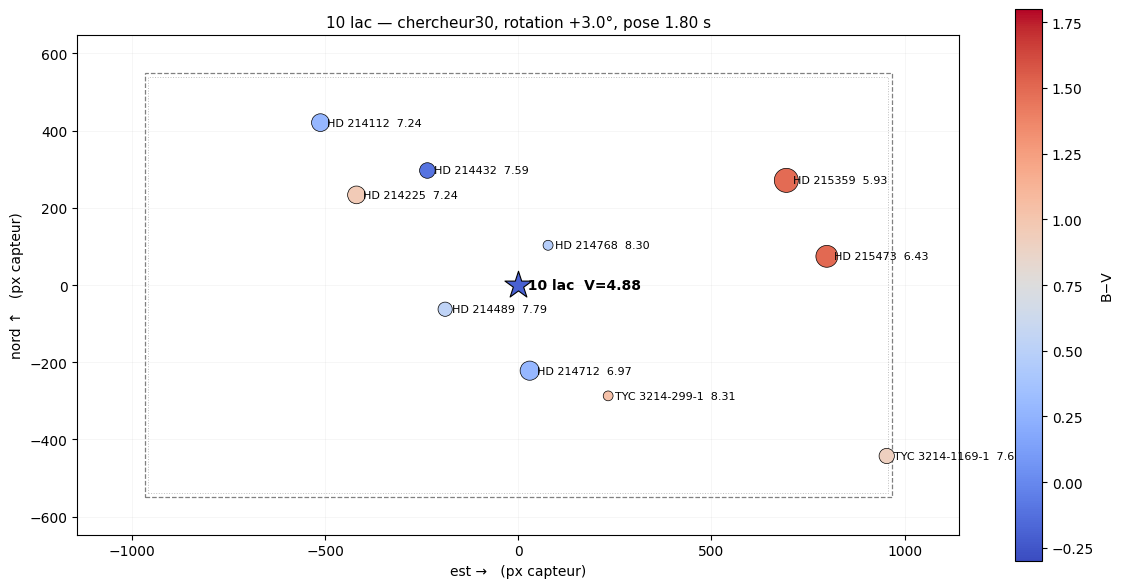

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

N_SHOW = 12
vue = propres[np.argsort(propres["score"])][:N_SHOW]

fig, ax = plt.subplots(figsize=(12, 7.2))
ax.add_patch(Rectangle((-HALF_X, -HALF_Y), NX, NY, fill=False,
                       ls="--", lw=0.9, ec="0.5"))
ax.add_patch(Rectangle((-HALF_X+EDGE_MARGIN, -HALF_Y+EDGE_MARGIN),
                       NX-2*EDGE_MARGIN, NY-2*EDGE_MARGIN,
                       fill=False, ls=":", lw=0.7, ec="0.75"))

v_lo, v_hi = float(np.nanmin(vue["V"])), float(np.nanmax(vue["V"]))
taille = lambda v: 50 + 250*(v_hi - v)/max(v_hi - v_lo, 0.1)
pts = ax.scatter(vue["x_E"], vue["y_N"], s=[taille(v) for v in vue["V"]],
                 c=vue["B_V"], cmap="coolwarm", vmin=-0.3, vmax=1.8,
                 edgecolors="k", linewidths=0.5, zorder=3)
ax.scatter([0], [0], s=420, marker="*", c=[[BV_T]], cmap="coolwarm",
           vmin=-0.3, vmax=1.8, edgecolors="k", linewidths=0.8, zorder=4)
ax.annotate(f"  {label_cible}  V={V_T:.2f}", (0, 0), fontsize=10,
            fontweight="bold", va="center", zorder=5)

for r in vue:
    ax.annotate(f"  {r['nom']}  {r['V']:.2f}", (r["x_E"], r["y_N"]),
                fontsize=8, va="center", zorder=5)
    if r["blend"]:
        ax.add_patch(Circle((r["x_E"], r["y_N"]), BLEND_RADIUS*1.6,
                            fill=False, ls=":", lw=0.8, ec="0.4"))

ax.set_xlim(-HALF_X*1.18, HALF_X*1.18)
ax.set_ylim(-HALF_Y*1.18, HALF_Y*1.18)
ax.set_aspect("equal")
ax.set_xlabel("est →   (px capteur)")
ax.set_ylabel("nord ↑   (px capteur)")
ax.set_title(f"{label_cible} — {INSTRUMENT}, rotation {ROT:+.1f}°, "
             f"pose {T_POSE:.2f} s", fontsize=11)
ax.grid(alpha=0.15, lw=0.5)
plt.colorbar(pts, ax=ax, label="B−V", shrink=0.8)
plt.tight_layout()
plt.show()

## 9. Carte de pointage

Vue conçue pour être comparée à l'aperçu de CCDciel : fond sombre, toutes les étoiles
du champ jusqu'à `PREVIEW_MAG` magnitudes sous la cible, taille des points
proportionnelle au flux et non à la magnitude, donc motif reconnaissable à l'œil.

`PREVIEW_FLIP_X` et `PREVIEW_FLIP_Y` sont à régler **une seule fois** : comparez cette
carte à une vraie image du champ et basculez les drapeaux jusqu'à superposition. Les
flèches nord et est tiennent compte de `ROT` et des deux drapeaux.

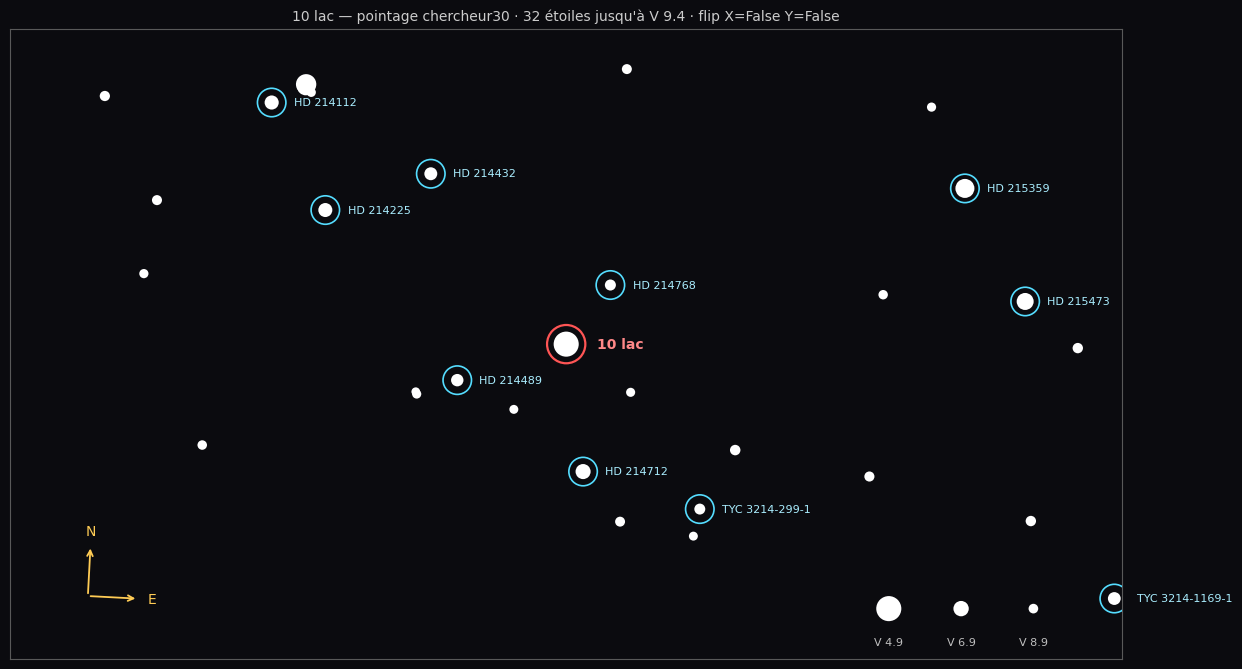

In [10]:
def preview_xy(x, y):
    x = -np.asarray(x, float) if PREVIEW_FLIP_X else np.asarray(x, float)
    y = -np.asarray(y, float) if PREVIEW_FLIP_Y else np.asarray(y, float)
    return x, y

# masque propre à la carte : contrairement à m_champ, il INCLUT la cible
dans_capteur = (np.abs(g_x) < HALF_X) & (np.abs(g_y) < HALF_Y)
vis = dans_capteur & (g_V < V_T + PREVIEW_MAG)
px, py = preview_xy(g_x[vis], g_y[vis])
pv = g_V[vis]

def taille_pt(v):
    """Taille du point ~ flux**0.55, comme une vraie image (bornée pour rester lisible)."""
    flux = 10**(-0.4*(np.asarray(v, dtype=float) - V_T))
    return np.clip(6 + 320*flux**0.55, 4, 700)

s_pt = taille_pt(pv)

fig, ax = plt.subplots(figsize=(12.5, 12.5*NY/NX))
ax.set_facecolor("#0b0b0f")
fig.patch.set_facecolor("#0b0b0f")
ax.scatter(px, py, s=s_pt, c="white", edgecolors="none", zorder=2)

# cible
tx, ty = preview_xy([0.0], [0.0])
ax.scatter(tx, ty, s=760, facecolors="none", edgecolors="#ff5555",
           lw=1.6, zorder=4)
ax.annotate(label_cible, (tx[0], ty[0]), textcoords="offset points",
            xytext=(22, 0), color="#ff8888", fontsize=10,
            fontweight="bold", va="center", zorder=5)

# comparaisons retenues
cx, cy = preview_xy(np.asarray(vue["x_E"], float), np.asarray(vue["y_N"], float))
ax.scatter(cx, cy, s=420, facecolors="none", edgecolors="#55ddff", lw=1.2, zorder=4)
for k, r in enumerate(vue):
    ax.annotate(str(r["nom"]), (cx[k], cy[k]), textcoords="offset points",
                xytext=(16, 0), color="#aaeeff", fontsize=8,
                va="center", zorder=5)

# orientation : nord et est projetés à travers ROT puis les flips
th = np.radians(ROT)
n_x, n_y = preview_xy([np.sin(th)], [np.cos(th)])
e_x, e_y = preview_xy([np.cos(th)], [-np.sin(th)])
ox, oy, L = -HALF_X*0.86, -HALF_Y*0.80, HALF_Y*0.16
for vx, vy, lab in ((n_x[0], n_y[0], "N"), (e_x[0], e_y[0], "E")):
    ax.annotate("", xy=(ox + vx*L, oy + vy*L), xytext=(ox, oy),
                arrowprops=dict(arrowstyle="->", color="#ffcc55", lw=1.3), zorder=5)
    ax.text(ox + vx*L*1.28, oy + vy*L*1.28, lab, color="#ffcc55",
            fontsize=10, ha="center", va="center", zorder=5)

# échelle de taille
for j, dm in enumerate((0.0, 2.0, 4.0)):
    xj = HALF_X*0.58 + j*HALF_X*0.13
    ax.scatter([xj], [-HALF_Y*0.84], s=float(taille_pt(V_T + dm)),
               c="white", edgecolors="none", zorder=5)
    ax.text(xj, -HALF_Y*0.93, f"V {V_T + dm:.1f}", color="0.75",
            fontsize=8, ha="center", va="top", zorder=5)

ax.set_xlim(-HALF_X, HALF_X)
ax.set_ylim(-HALF_Y, HALF_Y)
ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_color("0.35")
ax.set_title(f"{label_cible} — pointage {INSTRUMENT} · "
             f"{int(vis.sum())} étoiles jusqu'à V {V_T+PREVIEW_MAG:.1f} · "
             f"flip X={PREVIEW_FLIP_X} Y={PREVIEW_FLIP_Y}",
             color="0.8", fontsize=10)
plt.tight_layout()
plt.show()

## 10. Export

In [11]:
sortie = f"comparaisons_{label_cible.replace(' ', '_')}.csv"
T[T["ok"]][VUE][np.argsort(T[T["ok"]]["score"])].write(sortie, format="csv",
                                                       overwrite=True)
print(f"Écrit : {sortie}")

try:
    from google.colab import files
    files.download(sortie)
except ImportError:
    pass

Écrit : comparaisons_10_lac.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Limites à garder en tête

**`pic` est un ordre de grandeur, pas une prédiction.** Le pic ADU varie comme l'inverse
du carré de la FWHM : à 2.8 px au lieu de 2.0, il chute d'un facteur deux. `rate_ref` est
par ailleurs attaché à une configuration précise — gain, filtre, télescope. La pose
définitive se fixe toujours sur une image test.

**`gaia_to_V` et `bprp_to_BV` sont des approximations.** Remplacez la première par la
version validée de votre chaîne de réduction. La seconde n'est qu'un repli : dès qu'une
couleur GCPD, APASS ou Tycho existe, elle prend le dessus.

**`dV_src` signale, il n'exclut pas.** C'est l'étendue entre sources indépendantes. Un
écart marqué sur une étoile très bleue ou très rouge trahit le plus souvent une
transformation hors domaine, pas un problème sur l'étoile.

**Un couple serré n'est pas toujours disqualifiant.** Si les deux composantes ont la même
couleur, le rapport de flux ne dépend pas de la longueur d'onde et le blend se comporte
comme une source unique. Vérifiez les couleurs avant d'écarter.

**`ROT` doit venir d'un plate-solve**, pas de cette configuration. Une erreur de quelques
degrés déplace les étoiles de plusieurs dizaines de pixels en bord de champ.